# 🛍️ Retail Customer Satisfaction Insights

## Import Modules 📔📚

In [1]:
!python -m pip install -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


## 📁 Create Dataset

In [2]:
!python data_generate.py

Dataset 'customer_satisfaction_data.csv' generated successfully.


## 📌 Tasks Checklist

### 🔹 Data Preparation

In [3]:
df = pd.read_csv("customer_satisfaction_data.csv")

df.head(5)

df["Visit_Date"] = pd.to_datetime(df["Visit_Date"])
df["Visit_Month"] = df["Visit_Date"].dt.month
df["Visit_Weekday"] = df["Visit_Date"].dt.day_name()

rating_map = {1: "Very Unsatisfied", 2: "Unsatisfied", 3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"}
df["Total_Rating_in_words"] = df["Total_Rating"].map(rating_map)


### 🔹 Data Cleaning

In [4]:
df.isna().sum()

Survey_ID                  0
Customer_ID                0
Store_Location             0
Visit_Date                 0
Purchase_Amount            4
Wait_Time_Min              4
Staff_Rating               3
Product_Rating             6
Cleanliness_Rating         6
Recommend                  0
Total_Rating               2
Visit_Month                0
Visit_Weekday              0
Total_Rating_in_words    468
dtype: int64

In [5]:
df["Purchase_Amount"] = df["Purchase_Amount"].fillna(df["Purchase_Amount"].median())
df["Wait_Time_Min"] = df["Wait_Time_Min"].fillna(df["Wait_Time_Min"].median())
df["Staff_Rating"] = df["Staff_Rating"].fillna(df["Staff_Rating"].median())
df["Product_Rating"] = df["Product_Rating"].fillna(df["Product_Rating"].median())
df["Cleanliness_Rating"] = df["Cleanliness_Rating"].fillna(df["Cleanliness_Rating"].median())
df["Total_Rating"] = df["Total_Rating"].fillna(df["Total_Rating"].median())

df.isna().sum()

Survey_ID                  0
Customer_ID                0
Store_Location             0
Visit_Date                 0
Purchase_Amount            0
Wait_Time_Min              0
Staff_Rating               0
Product_Rating             0
Cleanliness_Rating         0
Recommend                  0
Total_Rating               0
Visit_Month                0
Visit_Weekday              0
Total_Rating_in_words    468
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(13)

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### 🔹 Data Visualization

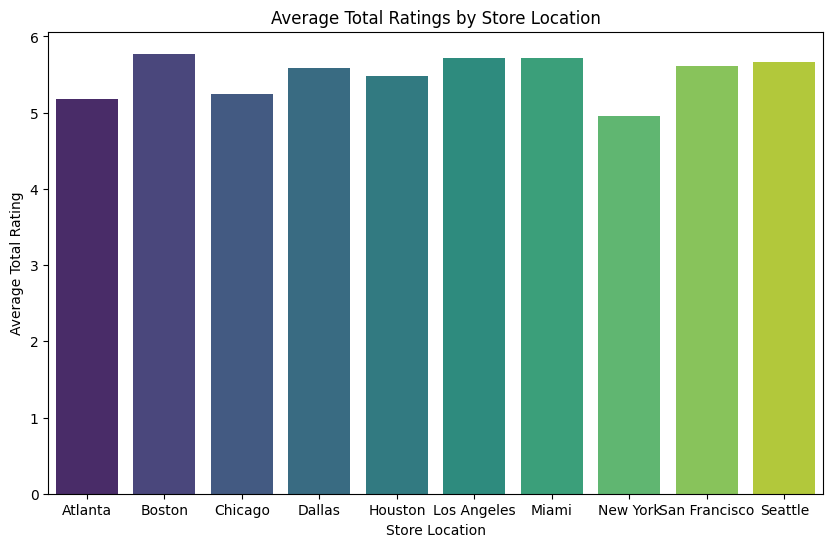

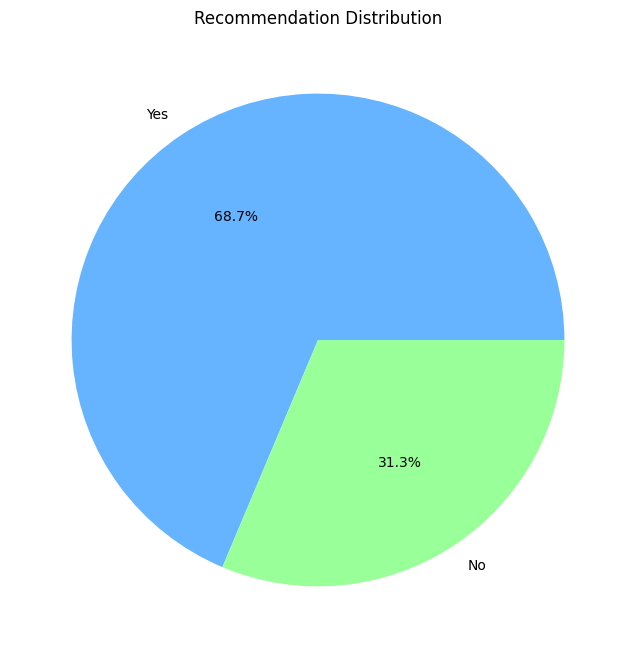

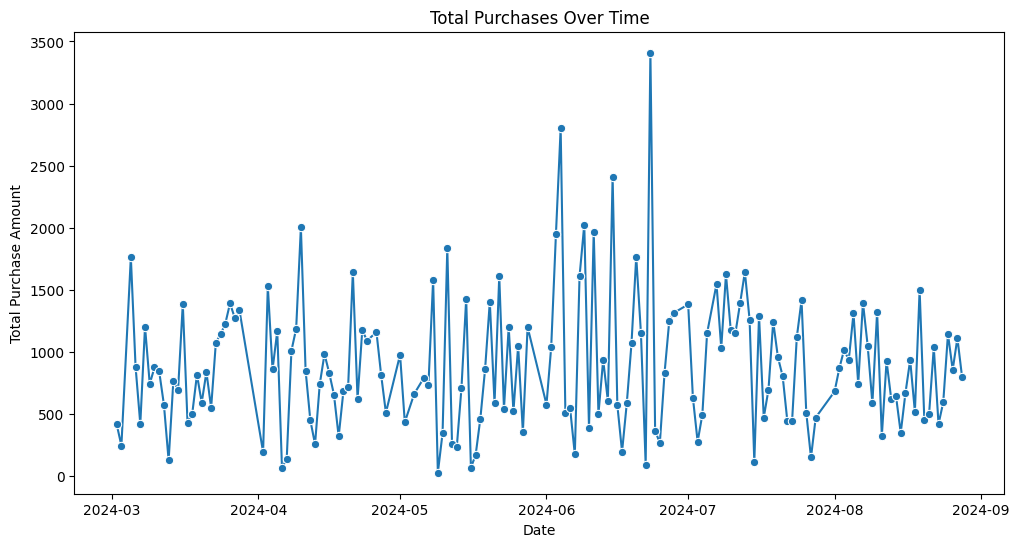

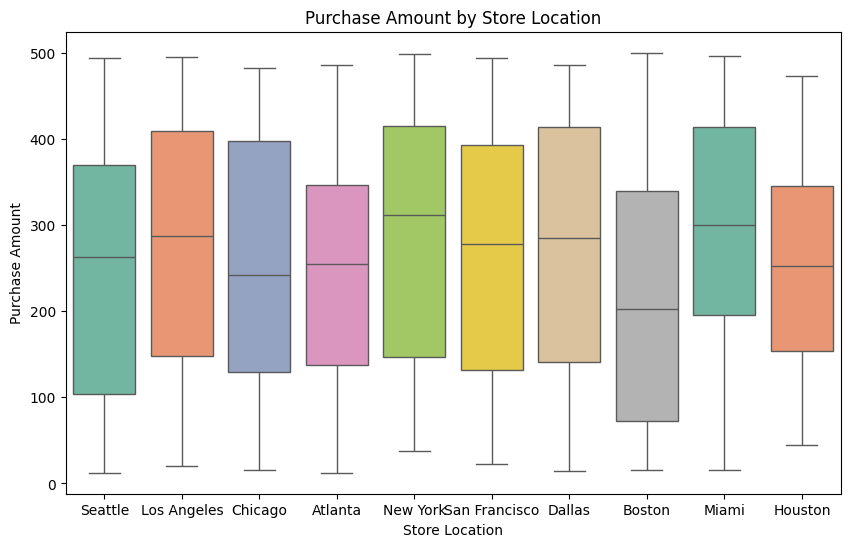

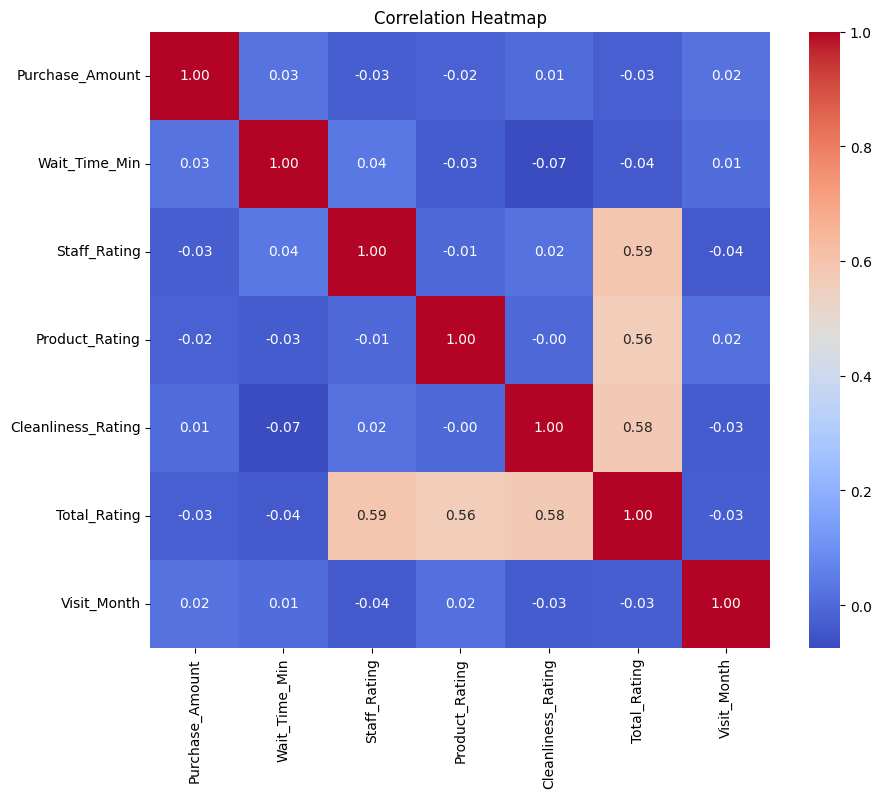

In [8]:
'''
8. Plot a bar chart of average ratings by store location.
9. Create a pie chart for recommendation distribution.
10. Plot a line chart of total purchases over time.
11. Use Seaborn:
   • Boxplot for Purchase_Amount by Store_Location.
   • Heatmap showing correlation between numeric variables.

'''
# 8. Plot a bar chart of average ratings by store location.
rating_map = {1: "Very Unsatisfied", 2: "Unsatisfied", 3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"}
avg_ratings = df.groupby("Store_Location")["Total_Rating"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_ratings, x="Store_Location", y="Total_Rating", palette="viridis", hue="Store_Location")
plt.title("Average Total Ratings by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Average Total Rating")
plt.show()
# 9. Create a pie chart for recommendation distribution.
recommendation_counts = df["Recommend"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(recommendation_counts, labels=recommendation_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title("Recommendation Distribution")
plt.show()
# 10. Plot a line chart of total purchases over time.
df['Visit_Date'] = pd.to_datetime(df['Visit_Date'])
purchases_over_time = df.groupby('Visit_Date')['Purchase_Amount'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=purchases_over_time, x='Visit_Date', y='Purchase_Amount', marker='o')
plt.title("Total Purchases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Purchase Amount")
plt.show()
# 11. Use Seaborn:
   # • Boxplot for Purchase_Amount by Store_Location.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Store_Location", y="Purchase_Amount", palette
="Set2", hue="Store_Location")
plt.title("Purchase Amount by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Purchase Amount")
plt.show()
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()